# 04 — Domain Adaptation Extensions

**Inputs:** preprocessed CSVs + `rf_calibrated.pkl` from Drive  
**No retraining of baselines** — weights are loaded directly.

**Extensions:**
- **A** Importance Weighting (covariate shift correction)
- **B** Label Shift Correction (prior probability adjustment)
- **C** Multi-scale MMD Neural Network


**Goal:** improve MIMIC external generalisation over the baseline best model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q imbalanced-learn xgboost torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os, pickle
warnings.filterwarnings('ignore')

from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics       import (roc_auc_score, average_precision_score,
                                   roc_curve, precision_recall_curve,
                                   confusion_matrix)
from sklearn.preprocessing import StandardScaler
from xgboost               import XGBClassifier
from collections           import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE      = '/content/drive/MyDrive/AI in Medicine/data/output_data/preprocessed'
MODEL_DIR = '/content/drive/MyDrive/AI in Medicine/models'
EXT_DIR   = f'{MODEL_DIR}/extensions'
os.makedirs(EXT_DIR, exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data and Baseline Weights

In [3]:
# ── Data
X_train = pd.read_csv(f'{BASE}/X_train.csv')
y_train = pd.read_csv(f'{BASE}/y_train.csv').squeeze()
X_val   = pd.read_csv(f'{BASE}/X_val.csv')
y_val   = pd.read_csv(f'{BASE}/y_val.csv').squeeze()
X_test  = pd.read_csv(f'{BASE}/X_test.csv')
y_test  = pd.read_csv(f'{BASE}/y_test.csv').squeeze()
X_mimic = pd.read_csv(f'{BASE}/X_mimic.csv')
y_mimic = pd.read_csv(f'{BASE}/y_mimic.csv').squeeze()

print(f'Loaded data — eicu: {X_train.shape}, mimic: {X_mimic.shape}')


Loaded data — eicu: (1512, 80), mimic: (136, 80)


In [4]:

# 1. Path
model_calibrated_path = os.path.join(MODEL_DIR, 'rf_calibrated.pkl')
model_uncalibrated_path = os.path.join(MODEL_DIR, 'rf_final.pkl')

# 2. Load files
with open(model_calibrated_path, 'rb') as f:
    rf_calibrated = pickle.load(f)

with open(model_uncalibrated_path, 'rb') as f:
    rf_final = pickle.load(f)

print('Models loaded!')
print(f'Тype rf_calibrated: {type(rf_calibrated)}')

Models loaded!
Тype rf_calibrated: <class 'sklearn.calibration.CalibratedClassifierCV'>


## Extract Best Params

In [5]:
import json as _json

# ── Load model weights
with open(os.path.join(MODEL_DIR, 'rf_calibrated.pkl'), 'rb') as f:
    rf_calibrated = pickle.load(f)

with open(os.path.join(MODEL_DIR, 'rf_final.pkl'), 'rb') as f:
    rf_final = pickle.load(f)

# ── Load best params saved by baseline notebook
params_path = os.path.join(MODEL_DIR, 'model_params.json')
with open(params_path) as f:
    _params = _json.load(f)

rf_best_params  = _params['rf_best_params']
rf_cal_thr      = _params['rf_cal_threshold']   # threshold from val set
scale_pos       = _params['scale_pos']

print('Models and params loaded from Drive:')
print(f'  rf_best_params  : {rf_best_params}')
print(f'  scale_pos       : {scale_pos:.1f}')
print(f'  rf_cal_threshold: {rf_cal_thr:.4f}')


Models and params loaded from Drive:
  rf_best_params  : {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 200}
  scale_pos       : 18.9
  rf_cal_threshold: 0.0444


In [6]:
# ── Load threshold config (label shift parameters)
with open(os.path.join(MODEL_DIR, 'threshold_config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

print('Threshold config loaded:')
print(f'  eICU threshold   : {cfg["eicu_threshold"]:.4f}')
print(f'  MIMIC threshold  : {cfg["mimic_threshold"]:.4f}')
print(f'  log-odds shift   : {cfg["log_odds_shift"]:.4f}')
print(f'  method           : {cfg["method"]}')

Threshold config loaded:
  eICU threshold   : 0.0440
  MIMIC threshold  : 0.3000
  log-odds shift   : 2.2722
  method           : label_shift_correction


## 2. Evaluation Utilities

In [7]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluate_model(model, X, y_true, label='', threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)
    cm    = confusion_matrix(y_true, pred)
    tn, fp, fn, tp = cm.ravel() if cm.shape==(2,2) else (0,0,0,int(y_true.sum()))
    return {
        'label': label,
        'ROC-AUC': roc_auc_score(y_true, proba),
        'PR-AUC':  average_precision_score(y_true, proba),
        'Sensitivity': tp/(tp+fn) if (tp+fn)>0 else 0.0,
        'Specificity': tn/(tn+fp) if (tn+fp)>0 else 0.0,
        'threshold': threshold, 'proba': proba, 'y_true': y_true,
    }

def best_threshold(model, X_val, y_val, min_spec=0.80):
    proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, thr = roc_curve(y_val, proba)
    spec  = 1 - fpr
    mask  = spec >= min_spec
    return float(thr[mask][np.argmax(tpr[mask])]) if mask.any() else float(thr[np.argmax(tpr-fpr)])

def print_row(label, r_val, r_test, r_mimic):
    print(f'{label:<28} '
          f'val={r_val["ROC-AUC"]:.3f}/{r_val["PR-AUC"]:.3f}  '
          f'test={r_test["ROC-AUC"]:.3f}/{r_test["PR-AUC"]:.3f}  '
          f'mimic={r_mimic["ROC-AUC"]:.3f}/{r_mimic["PR-AUC"]:.3f}')

def plot_roc_pr(results, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for r in results:
        fpr, tpr, _  = roc_curve(r['y_true'], r['proba'])
        prec, rec, _ = precision_recall_curve(r['y_true'], r['proba'])
        axes[0].plot(fpr, tpr,  label=f"{r['label']} ({r['ROC-AUC']:.3f})")
        axes[1].plot(rec, prec, label=f"{r['label']} ({r['PR-AUC']:.3f})")
    axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
    for ax, xl, yl, t in zip(axes, ['FPR','Recall'], ['TPR','Precision'], ['ROC','PR']):
        ax.set(xlabel=xl, ylabel=yl, title=f'{t} — {title}'); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

print('Utilities ready.')

Utilities ready.


## 3. Baseline Reference (from loaded weights)

In [8]:

best_model = rf_calibrated

base_val  = evaluate_model(best_model, X_val,   y_val,   label='RF Baseline (eICU val)',  threshold= rf_cal_thr )
base_test = evaluate_model(best_model, X_test,  y_test,  label='RF Baseline (eICU test)', threshold= rf_cal_thr )
base_mimic= evaluate_model(best_model, X_mimic, y_mimic, label='RF Baseline (MIMIC)',threshold=0.044) #Mimic thr


def get_metrics_df(results_list):
    # Extracts the 4 metrics from the result dictionaries
    data = []
    for r in results_list:
        data.append({
            'Dataset': r['label'],
            'ROC-AUC': r['ROC-AUC'],
            'PR-AUC': r['PR-AUC'],
            'Sensitivity': r['Sensitivity'],
            'Specificity': r['Specificity']
        })
    return pd.DataFrame(data)

# Collect results
results = [base_val, base_test, base_mimic]
df_metrics = get_metrics_df(results)

# Display as a clean table
print(df_metrics.to_string(index=False, formatters={
    'ROC-AUC': '{:.3f}'.format,
    'PR-AUC': '{:.3f}'.format,
    'Sensitivity': '{:.3f}'.format,
    'Specificity': '{:.3f}'.format
}))

                Dataset ROC-AUC PR-AUC Sensitivity Specificity
 RF Baseline (eICU val)   0.852  0.381       0.760       0.816
RF Baseline (eICU test)   0.827  0.398       0.720       0.758
    RF Baseline (MIMIC)   0.735  0.612       0.652       0.700


## Extension A — Label Shift Correction

Adjusts model output probabilities for the prior probability difference between eICU (5% mortality) and MIMIC (34% mortality). No retraining needed — applied post-hoc.

In [9]:
p_src = y_train.mean()
p_tgt = y_mimic.mean()
prior_log_odds_ratio = cfg['log_odds_shift']
mimic_threshold      = cfg['mimic_threshold']

print(f'eICU base-rate: {p_src:.3f}   MIMIC base-rate: {p_tgt:.3f}')
print(f'Prior log-odds adjustment: {prior_log_odds_ratio:.3f}')
print(f'MIMIC decision threshold : {mimic_threshold:.3f}')

class LabelShiftModel:
    def __init__(self, base_model, adjustment):
        self.base_model = base_model
        self.adjustment = adjustment
    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:,1].clip(1e-6, 1-1e-6)
        log_odds = np.log(raw / (1-raw)) + self.adjustment
        corrected = 1.0 / (1.0 + np.exp(-log_odds))
        return np.vstack([1-corrected, corrected]).T

ls_model_mimic = LabelShiftModel(best_model, prior_log_odds_ratio)
ls_model_zero  = LabelShiftModel(best_model, 0.0)

ls_val   = evaluate_model(ls_model_zero,  X_val,   y_val,   label='LS (val)',   threshold=rf_cal_thr)
ls_test  = evaluate_model(ls_model_zero,  X_test,  y_test,  label='LS (test)',  threshold=rf_cal_thr)
ls_mimic = evaluate_model(ls_model_mimic, X_mimic, y_mimic, label='LS (MIMIC)', threshold=mimic_threshold)

print_row('Label Shift Correction', ls_val, ls_test, ls_mimic)
print(f'  MIMIC sensitivity: {ls_mimic["Sensitivity"]:.3f}  specificity: {ls_mimic["Specificity"]:.3f}')

eICU base-rate: 0.050   MIMIC base-rate: 0.338
Prior log-odds adjustment: 2.272
MIMIC decision threshold : 0.300
Label Shift Correction       val=0.852/0.381  test=0.827/0.398  mimic=0.735/0.612
  MIMIC sensitivity: 0.696  specificity: 0.700


## Extension B — Importance Weighting (Covariate Shift)

Train a domain classifier (eICU vs MIMIC) and re-weight training samples to look more like MIMIC. Corrects for covariate shift.

In [15]:
# Step 1: Domain classifier
X_combined = np.vstack([X_train.values, X_mimic.values])
d_labels   = np.array([0]*len(X_train) + [1]*len(X_mimic))

domain_clf = LogisticRegression(max_iter=1000, random_state=SEED)
domain_clf.fit(X_combined, d_labels)
domain_auc = roc_auc_score(d_labels, domain_clf.predict_proba(X_combined)[:,1])
print(f'Domain classifier AUC: {domain_auc:.3f}  (>0.7 = significant covariate shift)')

# Step 2: Compute importance weights
p_target   = domain_clf.predict_proba(X_train.values)[:,1]
iw_weights = np.clip(p_target / (1 - p_target + 1e-6), 0.05, 20.0)
print(f'IW weights — min:{iw_weights.min():.3f}  max:{iw_weights.max():.3f}  mean:{iw_weights.mean():.3f}')

# Step 3: Retrain RF with importance weights
rf_iw_base = RandomForestClassifier(**rf_best_params, class_weight='balanced',
                                     random_state=SEED, n_jobs=-1)
rf_iw_cal  = CalibratedClassifierCV(rf_iw_base, method='sigmoid', cv=cv_strategy)
rf_iw_cal.fit(X_train, y_train, sample_weight=iw_weights)

iw_thr   = best_threshold(rf_iw_cal, X_val, y_val)
iw_val   = evaluate_model(rf_iw_cal, X_val,   y_val,   label='IW (val)',   threshold=iw_thr)
iw_test  = evaluate_model(rf_iw_cal, X_test,  y_test,  label='IW (test)',  threshold=iw_thr)
iw_mimic = evaluate_model(rf_iw_cal, X_mimic, y_mimic, label='IW (MIMIC)', threshold=iw_thr)

print_row('RF + Importance Weighting', iw_val, iw_test, iw_mimic)
print(f'  IW threshold (from val): {iw_thr:.4f}')

Domain classifier AUC: 0.984  (>0.7 = significant covariate shift)
IW weights — min:0.050  max:2.287  mean:0.071
RF + Importance Weighting    val=0.845/0.371  test=0.830/0.400  mimic=0.747/0.626
  IW threshold (from val): 0.1022


## Extension C — Multi-scale MMD Neural Network

Neural network with domain adaptation via Maximum Mean Discrepancy (MMD) loss using multiple RBF kernel scales. Reduces feature-space mismatch between eICU and MIMIC.

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

da_scaler  = StandardScaler()
X_tr_sc    = da_scaler.fit_transform(X_train.values)
X_val_sc   = da_scaler.transform(X_val.values)
X_test_sc  = da_scaler.transform(X_test.values)
X_mimic_sc = da_scaler.transform(X_mimic.values)
INPUT_DIM  = X_train.shape[1]

src_x_t = torch.tensor(X_tr_sc,    dtype=torch.float32)
src_y_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
tgt_x_t = torch.tensor(X_mimic_sc, dtype=torch.float32)

BATCH       = min(32, len(X_mimic) // 3)
src_loader  = DataLoader(TensorDataset(src_x_t, src_y_t), batch_size=BATCH, shuffle=True,  drop_last=True)
tgt_loader  = DataLoader(TensorDataset(tgt_x_t),          batch_size=BATCH, shuffle=True,  drop_last=True)

GAMMAS = [0.01, 0.1, 1.0]

def rbf_kernel(x, y, gamma):
    xn = (x**2).sum(1, keepdim=True)
    yn = (y**2).sum(1, keepdim=True)
    return torch.exp(-gamma * (xn + yn.t() - 2*x@y.t()).clamp(min=0))

def mmd_multiscale(sf, tf, gammas=GAMMAS):
    ns, nt = sf.size(0), tf.size(0)
    mmd = sum(
        rbf_kernel(sf,sf,g).sum()/(ns*ns)
        - 2*rbf_kernel(sf,tf,g).sum()/(ns*nt)
        + rbf_kernel(tf,tf,g).sum()/(nt*nt)
        for g in gammas
    )
    return mmd / len(gammas)

class MMDNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Linear(in_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),     nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16),     nn.BatchNorm1d(16), nn.ReLU()
        )
        self.clf  = nn.Sequential(nn.Linear(16,8), nn.ReLU(), nn.Linear(8,1), nn.Sigmoid())
    def forward(self, x):
        f = self.feat(x); return self.clf(f), f

class MMDWrapper:
    def __init__(self, model):
        self.model = model
    def predict_proba(self, X):
        self.model.eval()
        if isinstance(X, pd.DataFrame): X = X.values
        X_sc = da_scaler.transform(X)
        with torch.no_grad():
            t = torch.tensor(X_sc, dtype=torch.float32).to(device)
            p, _ = self.model(t)
            p = p.cpu().numpy().flatten()
        return np.vstack([1-p, p]).T

EPOCHS     = 60
LAMBDA_MAX = 0.3
pos_weight = torch.tensor([scale_pos], dtype=torch.float32).to(device)

mmd_net = MMDNet(INPUT_DIM).to(device)
opt     = optim.Adam(mmd_net.parameters(), lr=1e-3, weight_decay=1e-4)
sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
n_batch = min(len(src_loader), len(tgt_loader))

print(f'Training MMD network ({EPOCHS} epochs, batch={BATCH}, device={device})...')
for epoch in range(EPOCHS):
    mmd_net.train()
    lam = LAMBDA_MAX * (epoch / EPOCHS)
    src_iter = iter(src_loader); tgt_iter = iter(tgt_loader)
    for _ in range(n_batch):
        xs, ys = next(src_iter); xt = next(tgt_iter)[0]
        xs, ys, xt = xs.to(device), ys.to(device), xt.to(device)
        ps, fs = mmd_net(xs); _, ft = mmd_net(xt)
        w       = torch.where(ys==1, pos_weight.expand_as(ys), torch.ones_like(ys))
        task_l  = (w * nn.functional.binary_cross_entropy(ps, ys, reduction='none')).mean()
        loss    = task_l + lam * mmd_multiscale(fs, ft)
        opt.zero_grad(); loss.backward(); opt.step()
    sched.step()
    if (epoch+1) % 20 == 0:
        print(f'  Epoch {epoch+1}/{EPOCHS}  λ={lam:.3f}  loss={loss.item():.4f}')

mmd_wrapper = MMDWrapper(mmd_net)
mmd_thr   = best_threshold(mmd_wrapper, X_val, y_val)
mmd_val   = evaluate_model(mmd_wrapper, X_val,   y_val,   label='MMD (val)',   threshold=mmd_thr)
mmd_test  = evaluate_model(mmd_wrapper, X_test,  y_test,  label='MMD (test)',  threshold=mmd_thr)
mmd_mimic = evaluate_model(mmd_wrapper, X_mimic, y_mimic, label='MMD (MIMIC)', threshold=0.5)
print_row('Multi-scale MMD Net', mmd_val, mmd_test, mmd_mimic)

Device: cpu
Training MMD network (60 epochs, batch=32, device=cpu)...
  Epoch 20/60  λ=0.095  loss=1.0460
  Epoch 40/60  λ=0.195  loss=1.0161
  Epoch 60/60  λ=0.295  loss=1.7241
Multi-scale MMD Net          val=0.756/0.228  test=0.750/0.242  mimic=0.611/0.511


## 9. Final Comparison

In [18]:
print('=' * 95)
print(f'{"Method":<28}  {"Val ROC":>8}  {"Test ROC":>9}  {"MIMIC ROC":>10}  {"MIMIC Sens":>11}  {"MIMIC Spec":>11}')
print('-' * 95)
for label, r_v, r_t, r_m in [
    ('Baseline (RF cal.)',       base_val,  base_test,  base_mimic),
    ('+ Importance Weighting',   iw_val,    iw_test,    iw_mimic),
    ('+ Label Shift (thr=0.30)', ls_val,    ls_test,    ls_mimic),
    ('+ MMD Net',                mmd_val,   mmd_test,   mmd_mimic),
]:
    print(f'{label:<28}  '
          f'{r_v["ROC-AUC"]:>8.3f}  '
          f'{r_t["ROC-AUC"]:>9.3f}  '
          f'{r_m["ROC-AUC"]:>10.3f}  '
          f'{r_m["Sensitivity"]:>11.3f}  '
          f'{r_m["Specificity"]:>11.3f}')
print('=' * 95)

print('\nΔ ROC-AUC over Baseline on MIMIC:')
base_auc = base_mimic['ROC-AUC']
for label, r in [('IW', iw_mimic), ('Label Shift', ls_mimic), ('MMD', mmd_mimic)]:
    delta = r['ROC-AUC'] - base_auc
    mark  = '★' if delta > 0 else ' '
    print(f'  {mark} {label:<20} Δ={delta:+.3f}')

sens_gain = ls_mimic['Sensitivity'] - base_mimic['Sensitivity']
print(f'\nNote: Label Shift ROC-AUC is unchanged by design (ranking is preserved).')
print(f'      Sensitivity gain: {sens_gain:+.3f} ({base_mimic["Sensitivity"]:.3f} → {ls_mimic["Sensitivity"]:.3f}) using threshold 0.30 on corrected probs.')

Method                         Val ROC   Test ROC   MIMIC ROC   MIMIC Sens   MIMIC Spec
-----------------------------------------------------------------------------------------------
Baseline (RF cal.)               0.852      0.827       0.735        0.652        0.700
+ Importance Weighting           0.845      0.830       0.747        0.587        0.767
+ Label Shift (thr=0.30)         0.852      0.827       0.735        0.696        0.700
+ MMD Net                        0.756      0.750       0.611        0.478        0.778

Δ ROC-AUC over Baseline on MIMIC:
  ★ IW                   Δ=+0.012
    Label Shift          Δ=+0.000
    MMD                  Δ=-0.124

Note: Label Shift ROC-AUC is unchanged by design (ranking is preserved).
      Sensitivity gain: +0.043 (0.652 → 0.696) using threshold 0.30 on corrected probs.


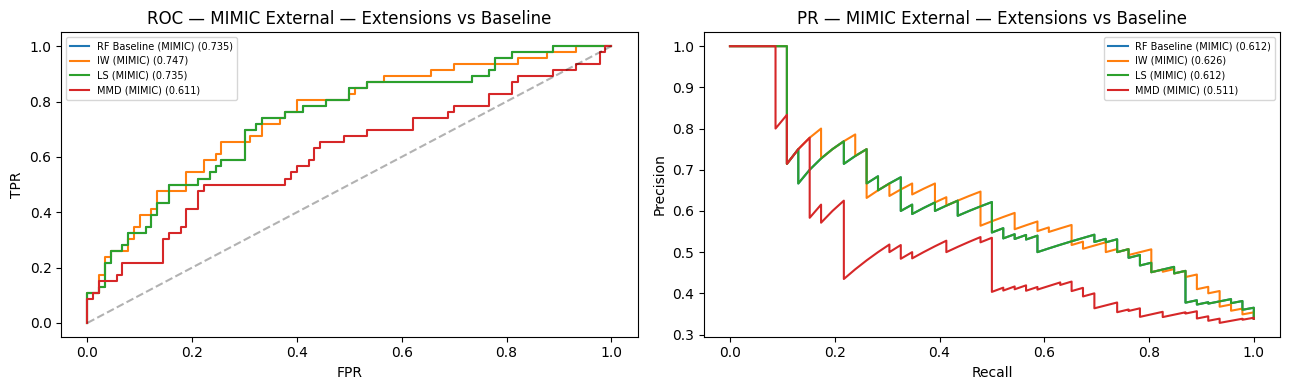

In [13]:
# Plot MIMIC curves for all extensions
mimic_results = [base_mimic, iw_mimic, ls_mimic, mmd_mimic]
plot_roc_pr(mimic_results, 'MIMIC External — Extensions vs Baseline')

## 10. Save Extension Models

In [19]:
extension_results = {
    'iw_model':       rf_iw_cal,
    'iw_threshold':   iw_thr,
    'iw_weights':     iw_weights,
    'domain_clf':     domain_clf,
    'mmd_net_state':  mmd_net.state_dict(),
    'da_scaler':      da_scaler,
    'mmd_threshold':  mmd_thr,
    'prior_log_odds': prior_log_odds_ratio,
    'results_mimic': {
        'baseline':  base_mimic['ROC-AUC'],
        'iw':        iw_mimic['ROC-AUC'],
        'ls':        ls_mimic['ROC-AUC'],
        'mmd':       mmd_mimic['ROC-AUC'],

    }
}

with open(f'{EXT_DIR}/extension_models.pkl', 'wb') as f:
    pickle.dump(extension_results, f)

print(f'Extension models saved to {EXT_DIR}/extension_models.pkl')

Extension models saved to /content/drive/MyDrive/AI in Medicine/models/extensions/extension_models.pkl
